In [2]:
import pandas as pd

df = pd.read_csv("Airbnb NYC 2019.csv")

print(df.head())

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/Lakshminandhini777/StaySense-AI-Airbnb-Analysis/main/Airbnb%20NYC%202019.csv"

df = pd.read_csv(url)
print(df.head())

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [34]:
url = "https://raw.githubusercontent.com/Lakshminandhini777/StaySense-AI-Airbnb-Analysis/main/Airbnb%20NYC%202019.csv"
df = pd.read_csv(url)

In [5]:
import pandas as pd

df = pd.read_csv("Airbnb NYC 2019.csv")

In [6]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [7]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(48895, 16)


In [8]:
print("\nData Types:")
print(df.dtypes)


Data Types:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [9]:
print("\nMissing Values Before Handling:")
print(df.isnull().sum())

df['name'].fillna("Unknown", inplace=True)
df['host_name'].fillna("Unknown", inplace=True)
df['last_review'].fillna("Not Reviewed", inplace=True)
df['reviews_per_month'].fillna(0, inplace=True)

print("\nMissing Values After Handling:")
print(df.isnull().sum())


Missing Values Before Handling:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Missing Values After Handling:
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                     

In [10]:
print("\nDuplicate Rows Before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate Rows After:", df.duplicated().sum())


Duplicate Rows Before: 0
Duplicate Rows After: 0


In [11]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print("\nLower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
outliers = df[(df['price'] < lower_limit) | (df['price'] > upper_limit)]
print("Number of Outliers:", outliers.shape[0])


Lower Limit: -90.0
Upper Limit: 334.0
Number of Outliers: 2972


In [12]:
df = df[(df['price'] >= lower_limit) & (df['price'] <= upper_limit)]
print("\nDataset Shape After Removing Outliers:")
print(df.shape)


Dataset Shape After Removing Outliers:
(45923, 16)


In [13]:
print("\nDataset Information:")
print(df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 45923 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              45923 non-null  int64  
 1   name                            45923 non-null  object 
 2   host_id                         45923 non-null  int64  
 3   host_name                       45923 non-null  object 
 4   neighbourhood_group             45923 non-null  object 
 5   neighbourhood                   45923 non-null  object 
 6   latitude                        45923 non-null  float64
 7   longitude                       45923 non-null  float64
 8   room_type                       45923 non-null  object 
 9   price                           45923 non-null  int64  
 10  minimum_nights                  45923 non-null  int64  
 11  number_of_reviews               45923 non-null  int64  
 12  last_review    

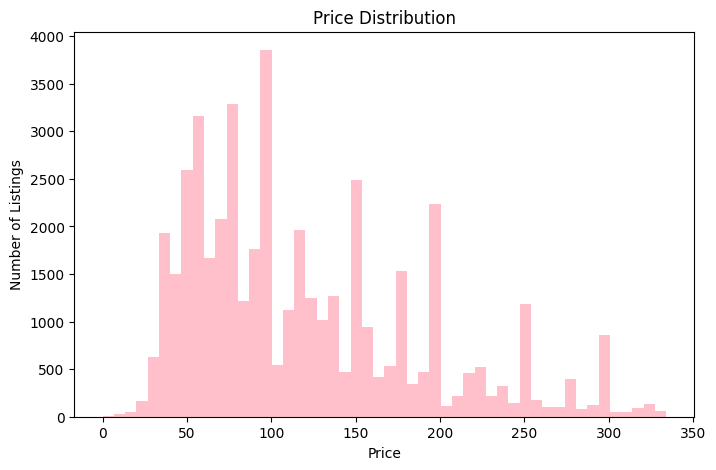

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=50, color='pink')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Number of Listings')
plt.show()

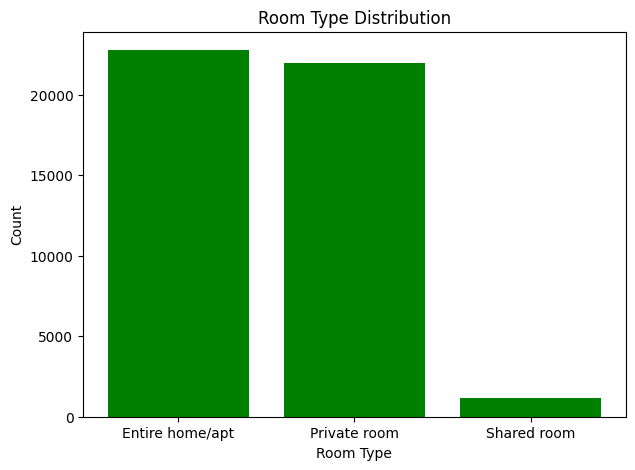

In [15]:
room_counts = df['room_type'].value_counts()

plt.figure(figsize=(7,5))
plt.bar(room_counts.index, room_counts.values, color='g')
plt.title('Room Type Distribution')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

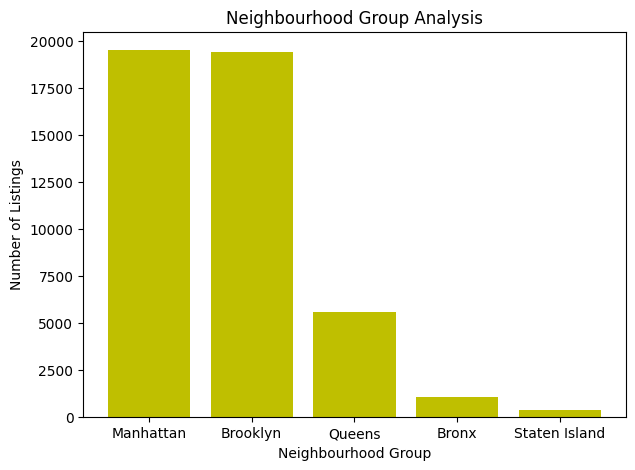

In [16]:
neighbourhood = df['neighbourhood_group'].value_counts()

plt.figure(figsize=(7,5))
plt.bar(neighbourhood.index, neighbourhood.values, color='y')
plt.title('Neighbourhood Group Analysis')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.show()

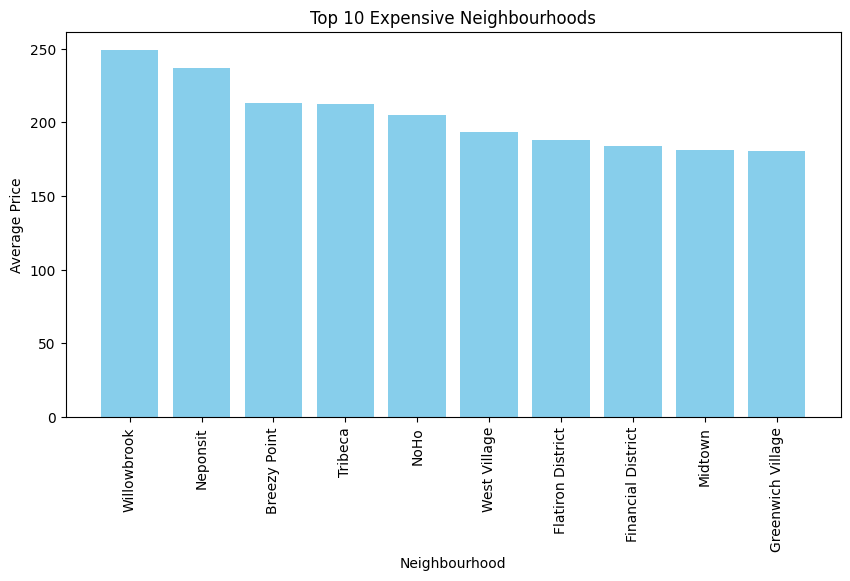

In [17]:
top_neighbourhoods = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_neighbourhoods.index, top_neighbourhoods.values,color='skyblue')
plt.xticks(rotation=90)
plt.title('Top 10 Expensive Neighbourhoods')
plt.xlabel('Neighbourhood')
plt.ylabel('Average Price')
plt.show()

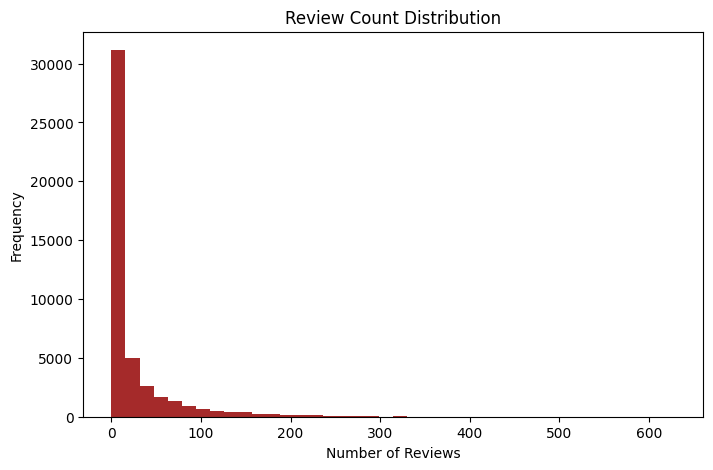

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df['number_of_reviews'], bins=40, color='brown')
plt.title('Review Count Distribution')
plt.xlabel('Number of Reviews')
plt.ylabel('Frequency')
plt.show()

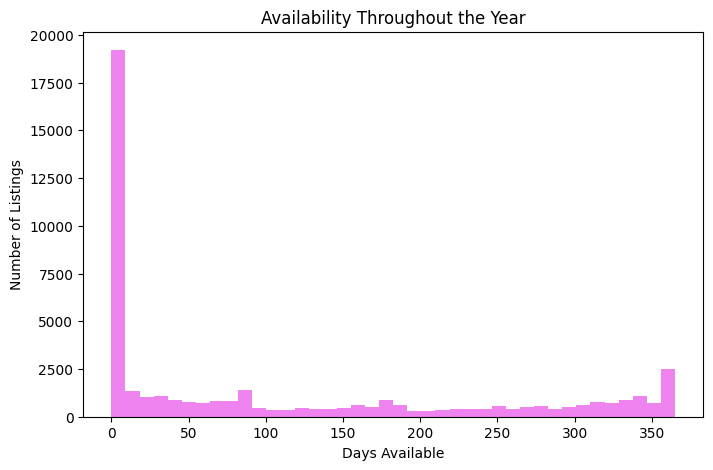

In [19]:
plt.figure(figsize=(8,5))
plt.hist(df['availability_365'], bins=40, color='violet')
plt.title('Availability Throughout the Year')
plt.xlabel('Days Available')
plt.ylabel('Number of Listings')
plt.show()

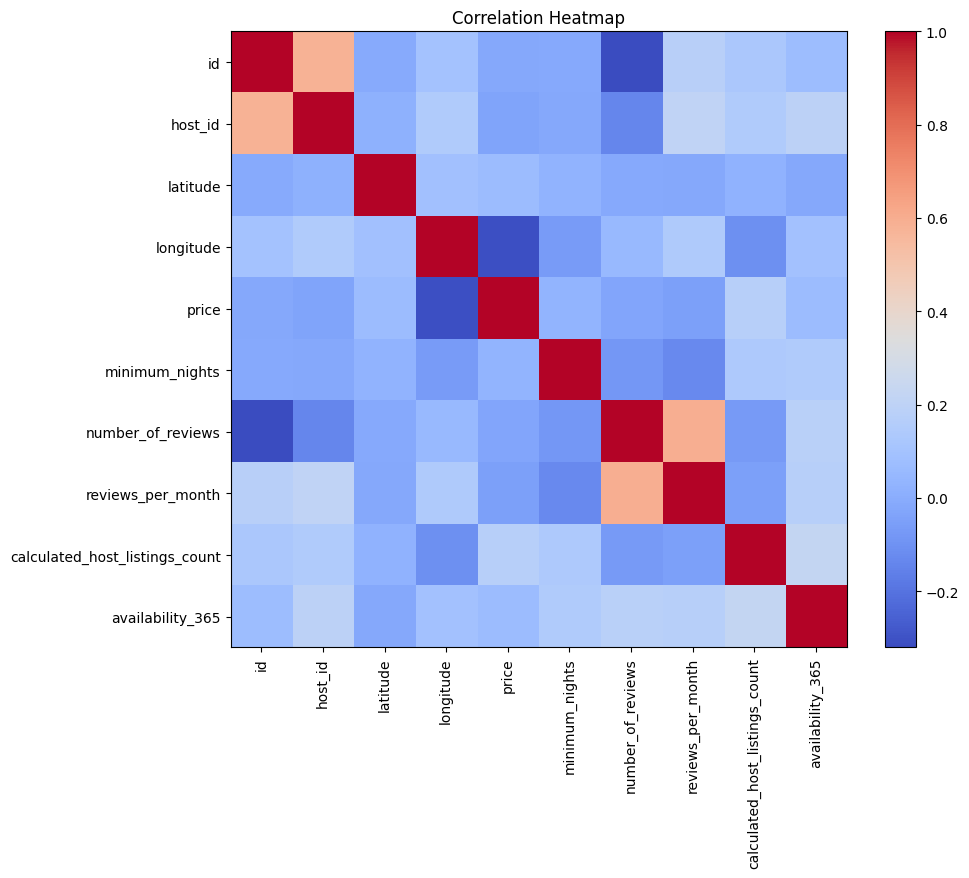

In [20]:

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
plt.imshow(numeric_df.corr(), cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)
plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)

plt.title("Correlation Heatmap")
plt.show()

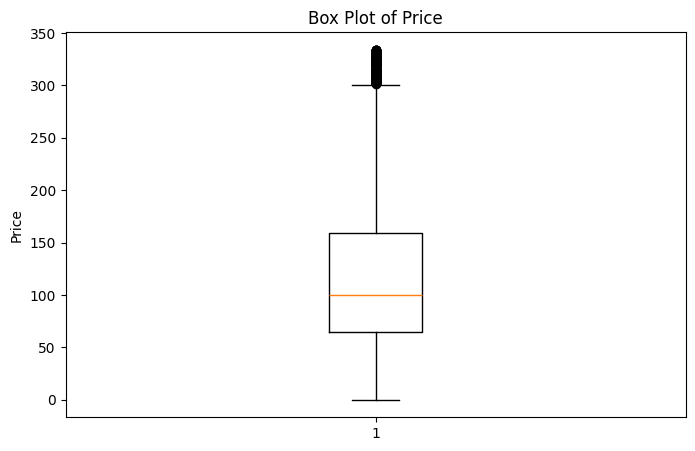

In [21]:
plt.figure(figsize=(8,5))
plt.boxplot(df['price'])
plt.title('Box Plot of Price')
plt.ylabel('Price')
plt.show()

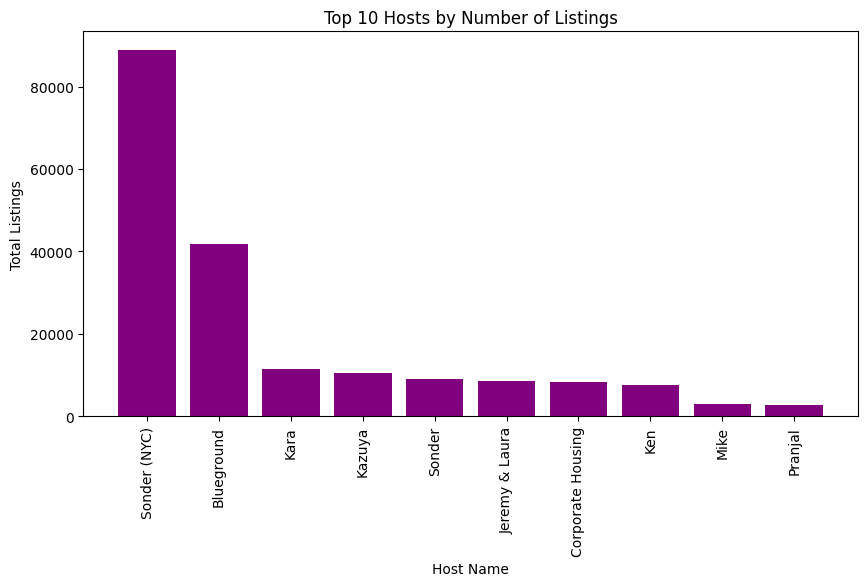

In [22]:
host_listings = df.groupby('host_name')['calculated_host_listings_count'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(host_listings.index, host_listings.values, color='purple')
plt.xticks(rotation=90)
plt.title('Top 10 Hosts by Number of Listings')
plt.xlabel('Host Name')
plt.ylabel('Total Listings')
plt.show()

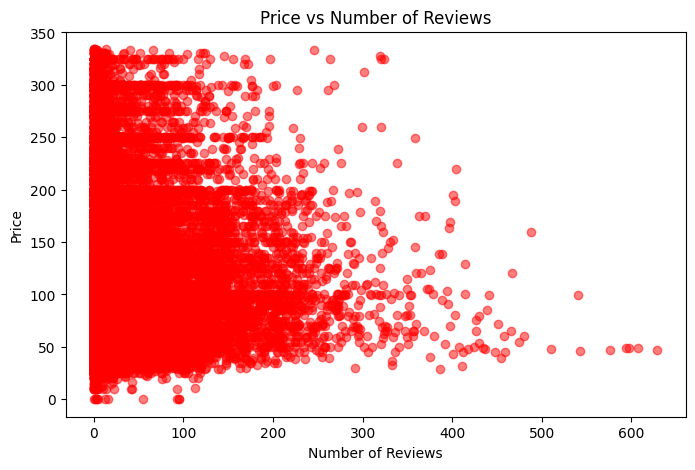

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(df['number_of_reviews'], df['price'], alpha=0.5,color='red')
plt.title('Price vs Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Price')
plt.show()

In [24]:
# Select useful features
features = ['neighbourhood_group',
            'room_type',
            'minimum_nights',
            'number_of_reviews',
            'reviews_per_month',
            'calculated_host_listings_count',
            'availability_365']

X = df[features]
y = df['price']

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X['neighbourhood_group'] = le.fit_transform(X['neighbourhood_group'])
X['room_type'] = le.fit_transform(X['room_type'])

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (36738, 7)
Testing Data : (9185, 7)


In [27]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [28]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, y_true, y_pred):
    print("\n", "="*35)
    print(name)
    print("="*35)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("MAE :", round(mae,2))
    print("MSE :", round(mse,2))
    print("RMSE:", round(rmse,2))
    print("R² Score:", round(r2,3))
evaluate_model("Linear Regression", y_test, lr_pred)
evaluate_model("Decision Tree", y_test, dt_pred)
evaluate_model("Random Forest", y_test, rf_pred)


Linear Regression
MAE : 40.6
MSE : 2857.24
RMSE: 53.45
R² Score: 0.387

Decision Tree
MAE : 46.13
MSE : 4225.6
RMSE: 65.0
R² Score: 0.093

Random Forest
MAE : 36.56
MSE : 2534.05
RMSE: 50.34
R² Score: 0.456


In [31]:
results = {
    "Model":["Linear Regression",
             "Decision Tree",
             "Random Forest"],

    "R2 Score":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
}

import pandas as pd

comparison = pd.DataFrame(results)

print(comparison)

comparison.sort_values(by="R2 Score", ascending=False)

               Model  R2 Score
0  Linear Regression  0.386630
1      Decision Tree  0.092880
2      Random Forest  0.456009


,Model,R2 Score
2,Random Forest,0.456009
0,Linear Regression,0.386630
1,Decision Tree,0.092880


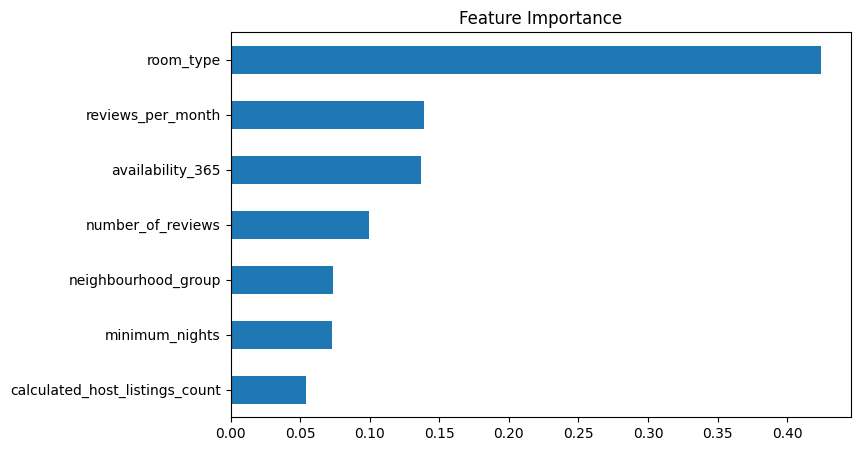

In [32]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh', figsize=(8,5))

plt.title("Feature Importance")

plt.show()

<BarContainer object of 3 artists>

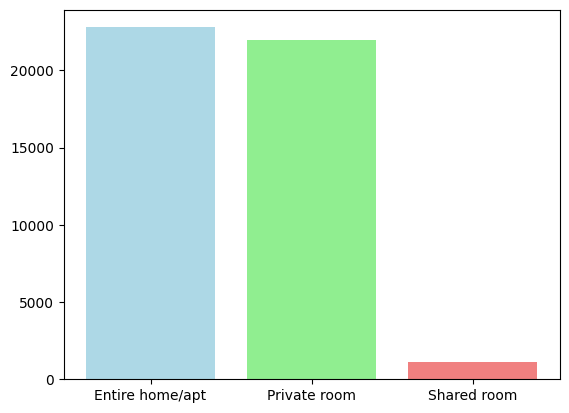

In [33]:
colors = ['lightblue', 'lightgreen', 'lightcoral']

plt.bar(room_counts.index, room_counts.values, color=colors)